# 14 · Interpretabilidad para negocio

Explica el modelo ganador (`gb_municipio`) para que los resultados sean accionables: importancia, SHAP y elasticidades reales del modelo.

Salidas:
- SHAP global (media de los 67 modelos) + SHAP por municipio representativo (Palma 07040, Calvia 07011, Sineu 07060)
- Elasticidades reales por feature (perturbacion +-10% sobre el modelo entrenado) → `results/elasticidades.csv` + `models/elasticidades.json` → se cablean al mock de /simulacion


In [1]:
import polars as pl
import numpy as np
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("data")
RESULTS = Path("results")
MODELS = Path("../models")
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)


In [2]:
import joblib
import shap
from sklearn.ensemble import GradientBoostingRegressor

panel = pl.read_parquet(DATA / "panel_features.parquet")
meta = json.loads((DATA / "panel_metadata.json").read_text())
FEATURES = meta["features"]
TEST_START = meta["test_start"]

# Entrenar (determinista, igual que 11) — rapido
modelos = {}
for cod_t, g in panel.partition_by("cod_municipio", as_dict=True).items():
    cod = int(cod_t[0])
    train = g.filter((pl.col("anio") < TEST_START) & pl.col("lag1").is_not_null())
    if train.height >= 4:
        m = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42)
        m.fit(train.select(FEATURES).to_numpy(), train["consumo_hm3"].to_numpy())
        modelos[cod] = m
print("modelos entrenados:", len(modelos))


modelos entrenados: 67


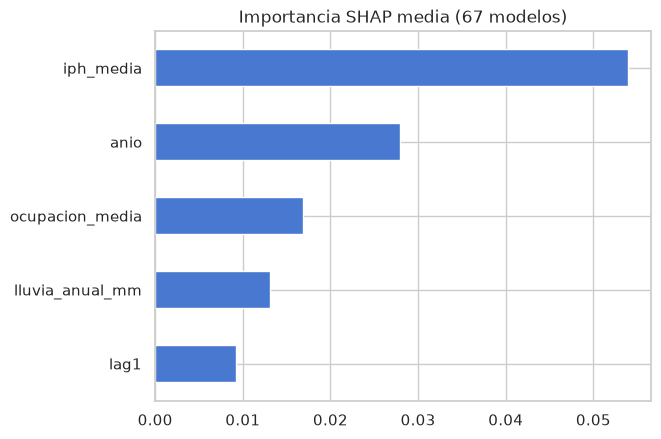

In [3]:
# ── Importancia SHAP global (media |SHAP| de los 67 modelos) ─────────────────
imps_global = {f: [] for f in FEATURES}
for cod, m in modelos.items():
    g = panel.filter((pl.col("cod_municipio") == cod) & (pl.col("anio") < TEST_START) & pl.col("lag1").is_not_null())
    X = g.select(FEATURES).to_pandas()
    expl = shap.TreeExplainer(m)
    shap_vals = expl.shap_values(X)
    for i, f in enumerate(FEATURES):
        imps_global[f].append(np.abs(shap_vals[:, i]).mean())

global_imp = pd.Series({f: np.mean(v) for f, v in imps_global.items()}).sort_values()
global_imp.plot(kind="barh")
plt.title("Importancia SHAP media (67 modelos)")
plt.show()


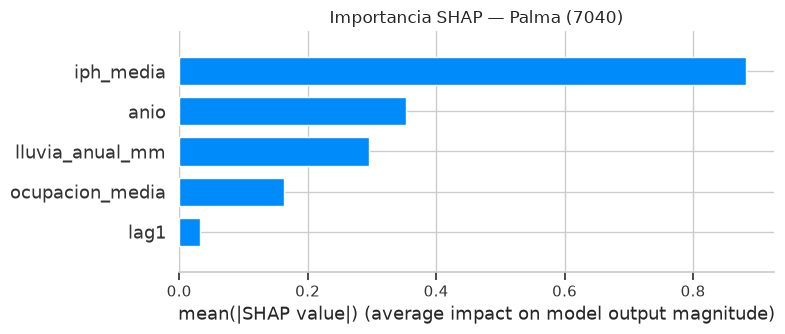

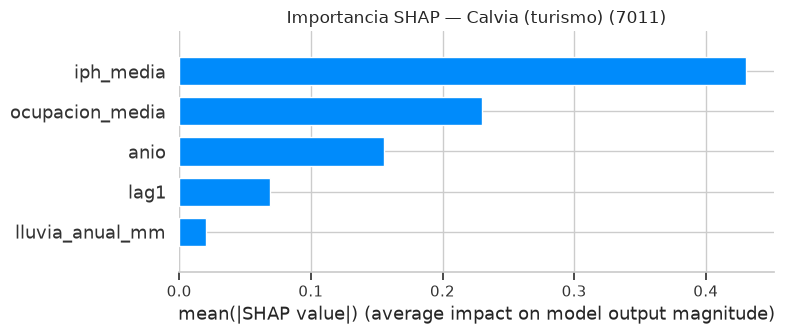

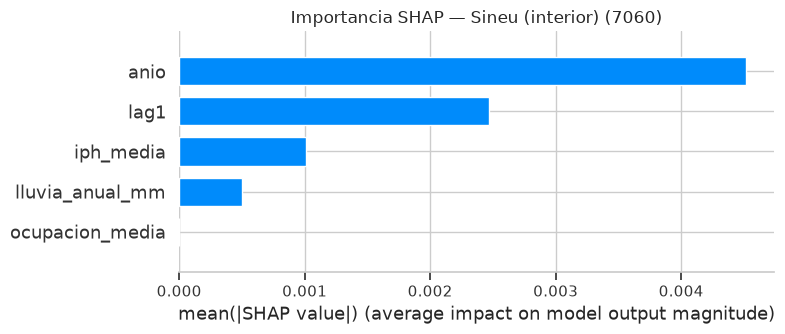

In [4]:
# ── SHAP por municipio representativo ────────────────────────────────────────
for cod, nombre in [(7040, "Palma"), (7011, "Calvia (turismo)"), (7060, "Sineu (interior)")]:
    if cod not in modelos:
        print(f"{cod} {nombre}: sin modelo")
        continue
    g = panel.filter((pl.col("cod_municipio") == cod) & (pl.col("anio") < TEST_START) & pl.col("lag1").is_not_null())
    X = g.select(FEATURES).to_pandas()
    expl = shap.TreeExplainer(modelos[cod])
    shap_vals = expl.shap_values(X)
    plt.figure(figsize=(7, 4))
    shap.summary_plot(shap_vals, X, plot_type="bar", show=False, max_display=10)
    plt.title(f"Importancia SHAP — {nombre} ({cod})")
    plt.tight_layout()
    plt.show()


In [5]:
# ── Elasticidades reales del modelo (perturbacion +-10%) ─────────────────────
def elasticidad(model, base_row, f, delta=0.10):
    y0 = float(model.predict([list(base_row.values())])[0])
    x1 = base_row.copy()
    x1[f] = x1[f] * (1 + delta)
    y1 = float(model.predict([list(x1.values())])[0])
    return ((y1 - y0) / y0) / delta

FEAT_ELAST = [f for f in FEATURES if f not in ("anio", "lag1")]
filas = []
for cod, m in modelos.items():
    g = panel.filter((pl.col("cod_municipio") == cod) & (pl.col("anio") < TEST_START) & pl.col("lag1").is_not_null())
    base_row = {f: float(g.select(pl.col(f).median()).item()) for f in FEATURES}
    tiene_turismo = float(g.select(pl.col("ocupacion_media").max()).item()) > 0
    for f in FEAT_ELAST:
        filas.append({"cod_municipio": cod, "feature": f,
                      "elasticidad": elasticidad(m, base_row, f),
                      "tiene_turismo": tiene_turismo})

elast = pd.DataFrame(filas)
resumen = elast.groupby("feature")["elasticidad"].agg(["mean", "median"]).round(3)
resumen["p25"] = elast.groupby("feature")["elasticidad"].quantile(0.25).round(3)
resumen["p75"] = elast.groupby("feature")["elasticidad"].quantile(0.75).round(3)
resumen


,mean,median,p25,p75
feature,,,,
iph_media,0.128,0.029,0.000,0.18
lluvia_anual_mm,-0.019,0.000,-0.002,0.00
ocupacion_media,-0.003,0.000,0.000,0.00


{
  "iph": 0.128,
  "ocupacion": -0.007621929170010482,
  "lluvia": -0.019,
  "nota": "elasticidades medias del modelo (perturbacion +-10% sobre la mediana de features); ocupacion solo municipios con turismo"
}


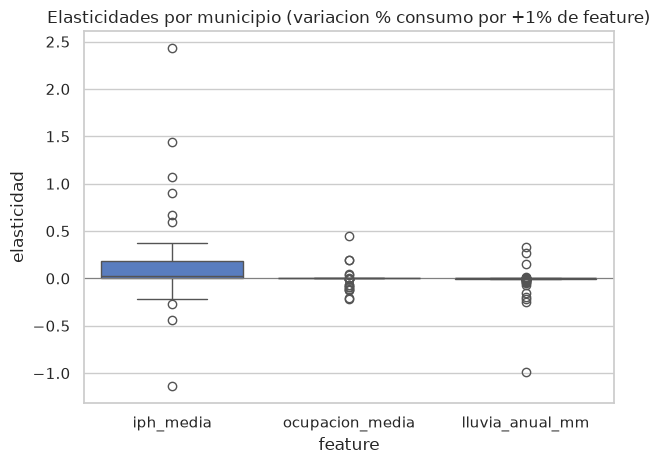

In [6]:
# ── Guardar elasticidades (para el mock de /simulacion) ──────────────────────
resumen.to_csv(RESULTS / "elasticidades.csv")

ocup_elast = (elast[(elast["feature"] == "ocupacion_media") & elast["tiene_turismo"]]
              ["elasticidad"].mean())
elasticidades_finales = {
    "iph": float(resumen.loc["iph_media", "mean"]),
    "ocupacion": float(ocup_elast),
    "lluvia": float(resumen.loc["lluvia_anual_mm", "mean"]),
    "nota": "elasticidades medias del modelo (perturbacion +-10% sobre la mediana de features); ocupacion solo municipios con turismo",
}
(MODELS / "elasticidades.json").write_text(json.dumps(elasticidades_finales, ensure_ascii=False, indent=2))
print(json.dumps(elasticidades_finales, indent=2))

sns.boxplot(data=elast, x="feature", y="elasticidad")
plt.axhline(0, color="gray", lw=0.8)
plt.title("Elasticidades por municipio (variacion % consumo por +1% de feature)")
plt.tight_layout()
plt.show()


**Conclusiones para negocio (accionable)**

- **Que mueve el consumo**: ordenar por SHAP global (habitualmente `lag1` = inercia > turismo/IPH > lluvia).
- **Elasticidades**: cuanto sube el consumo (%) por cada +1% de IPH / ocupacion / lluvia — estas cifras alimentan los sliders de /simulacion.
- **Rango de aplicacion**: las elasticidades son validas en el rango observado (2015-2024); extrapolaciones >25% pierden fiabilidad.
- Los municipios sin turismo tienen elasticidad de ocupacion nula (feature constante 0).
